In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
salary = [11, 40, 45, 68, 65, 68, 78, 90, 57, 74, 91, 92, 88, 68, 57, 48, 99, 101, 68, 77, 110, 140]

In [3]:
salary

[11,
 40,
 45,
 68,
 65,
 68,
 78,
 90,
 57,
 74,
 91,
 92,
 88,
 68,
 57,
 48,
 99,
 101,
 68,
 77,
 110,
 140]

In [4]:
#five point summary
#min,25 perc,50 perc, 75 perc, 100 perc


In [5]:
np.quantile(salary, [0, 0.25, 0.5, 0.75, 1])

array([ 11.  ,  59.  ,  71.  ,  90.75, 140.  ])

In [6]:
df=pd.DataFrame(salary,columns=['salary'])

In [7]:
df.describe()

,salary
count,22.000000
mean,74.318182
std,27.201867
min,11.000000
25%,59.000000
50%,71.000000
75%,90.750000
max,140.000000


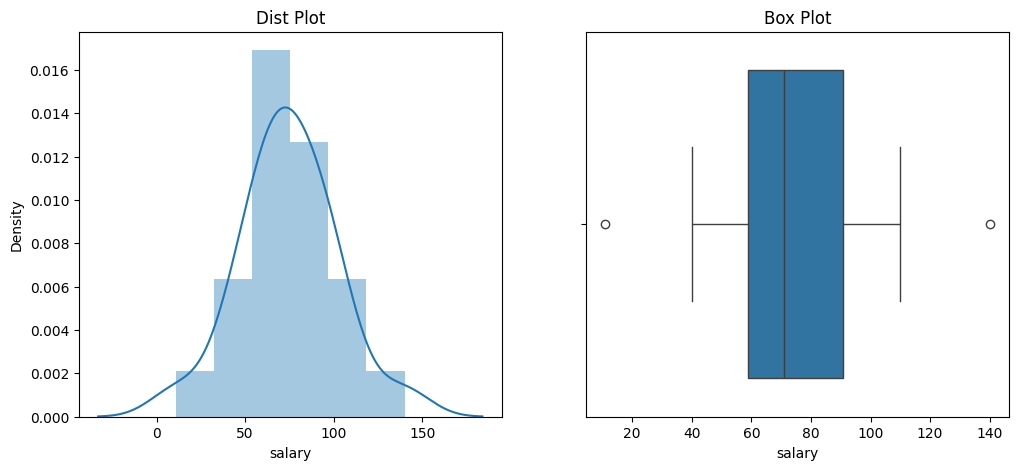

In [8]:
#to check outliers>>distplot,boxplot
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.distplot(df['salary'],kde=True)
plt.title("Dist Plot")

plt.subplot(1,2,2)
sns.boxplot(data=df,x='salary')
plt.title("Box Plot")
plt.show()

In [9]:
#here the distribution is not skewed as the outliers are present on both side
#In box plot, we see there are outliers

#dropping the outlier

#replace with mean and median

#capping the outlier

#dropping the outlier


In [10]:
Q1=df.salary.quantile(0.25)
Q3=df.salary.quantile(0.75)

IQR=Q3-Q1

lower_fence=Q1-1.5*IQR
upper_fence=Q3+1.5*IQR

In [11]:
df_filtered=df[(df.salary>lower_fence) & (df.salary<upper_fence)]

In [12]:
df.shape

(22, 1)

In [13]:
df_filtered.shape

(20, 1)

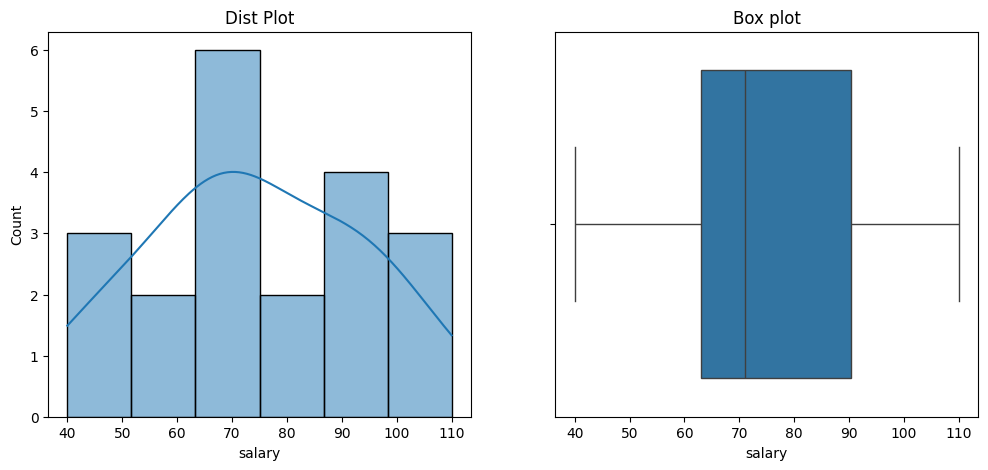

In [16]:
plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_filtered['salary'], kde = True)
plt.title("Dist Plot")


plt.subplot(1, 2, 2)
sns.boxplot(data=df_filtered, x = 'salary')
plt.title("Box plot")
plt.show()

In [17]:
#imputation with mean
df['salary_imputed_mean']=np.where((df.salary<lower_fence) | (df.salary>upper_fence), df.salary.mean(), df.salary)

In [18]:
df

,salary,salary_imputed_mean
0,11,74.318182
1,40,40.000000
2,45,45.000000
3,68,68.000000
4,65,65.000000
5,68,68.000000
6,78,78.000000
7,90,90.000000
8,57,57.000000
9,74,74.000000


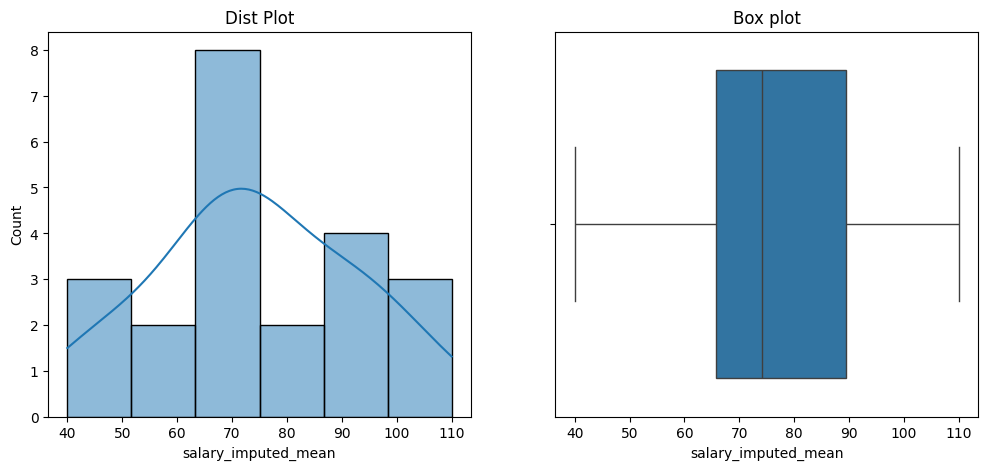

In [20]:
plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['salary_imputed_mean'], kde = True)
plt.title("Dist Plot")


plt.subplot(1, 2, 2)
sns.boxplot(data=df, x = 'salary_imputed_mean')
plt.title("Box plot")
plt.show()

In [22]:
#imputation with median
df['salary_imputed_median'] = np.where((df.salary >= upper_fence) | (df.salary <= lower_fence), df['salary'].median(), df['salary'])

In [24]:
df

,salary,salary_imputed_mean,salary_imputed_median
0,11,74.318182,71.0
1,40,40.000000,40.0
2,45,45.000000,45.0
3,68,68.000000,68.0
4,65,65.000000,65.0
5,68,68.000000,68.0
6,78,78.000000,78.0
7,90,90.000000,90.0
8,57,57.000000,57.0
9,74,74.000000,74.0


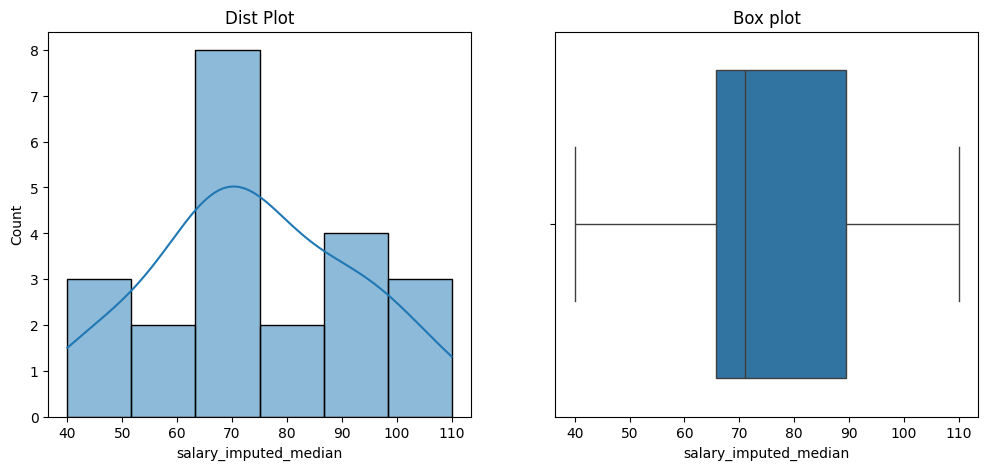

In [23]:
plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['salary_imputed_median'], kde = True)
plt.title("Dist Plot")


plt.subplot(1, 2, 2)
sns.boxplot(data=df, x = 'salary_imputed_median')
plt.title("Box plot")
plt.show()

In [25]:
#capping >> replacing the nearest value which is not outlier
df

,salary,salary_imputed_mean,salary_imputed_median
0,11,74.318182,71.0
1,40,40.000000,40.0
2,45,45.000000,45.0
3,68,68.000000,68.0
4,65,65.000000,65.0
5,68,68.000000,68.0
6,78,78.000000,78.0
7,90,90.000000,90.0
8,57,57.000000,57.0
9,74,74.000000,74.0


In [27]:
lower_cap = df['salary'].quantile(0.05) #lower cao is 5th percentile
upper_cap = df['salary'].quantile(0.95) #upper cap as 95th percentile

In [28]:
lower_cap

np.float64(40.25)

In [29]:
upper_cap

np.float64(109.55)

In [30]:
#replace outliers with cap
# where(condition, [x, y], /)
# Return elements chosen from `x` or `y` depending on `condition`.
#if df['salary'] < lower_cap satisfied then lower_cap and df['salary']>upper_cap satisfied then upper_cap
#otherwise keep salary as it is
df["salary_capped"] = np.where(df['salary'] < lower_cap, lower_cap,
        np.where(df['salary']>upper_cap, upper_cap, df['salary']))

In [31]:
df

,salary,salary_imputed_mean,salary_imputed_median,salary_capped
0,11,74.318182,71.0,40.25
1,40,40.000000,40.0,40.25
2,45,45.000000,45.0,45.00
3,68,68.000000,68.0,68.00
4,65,65.000000,65.0,65.00
5,68,68.000000,68.0,68.00
6,78,78.000000,78.0,78.00
7,90,90.000000,90.0,90.00
8,57,57.000000,57.0,57.00
9,74,74.000000,74.0,74.00


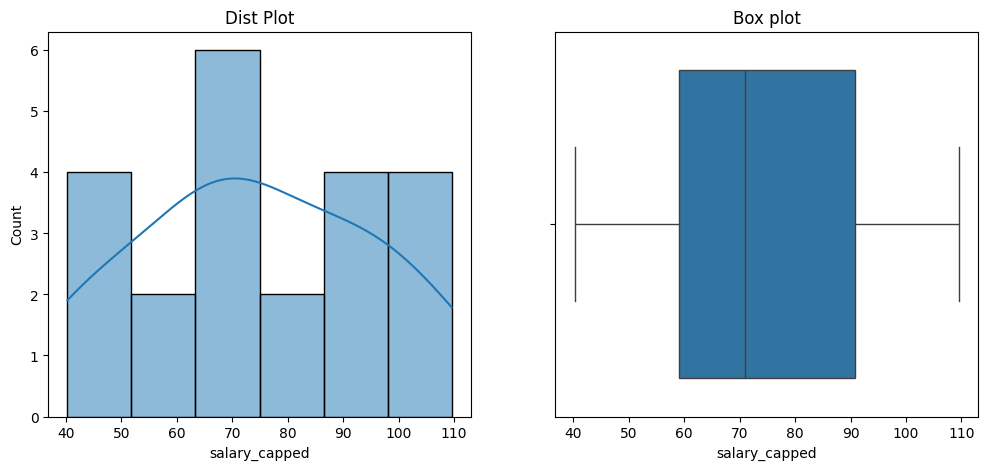

In [32]:
plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['salary_capped'], kde = True)
plt.title("Dist Plot")


plt.subplot(1, 2, 2)
sns.boxplot(data=df, x = 'salary_capped')
plt.title("Box plot")
plt.show()